In [11]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END

## Reducers
from typing import Annotated
from langgraph.graph import add_messages


In [12]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [13]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [14]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o-mini")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5d8d1116aa', 'id': 'chatcmpl-E7aawSNg9LPFJkqOYCxwrmNit5ge2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fb6c3-3125-7e53-aa25-a2e67d577058-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [19]:
from langchain_groq import ChatGroq
llm_groq=ChatGroq(model="llama-3.3-70b-versatile")
llm_groq.invoke("Hello")

AIMessage(content='Hello. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.028950018, 'completion_tokens_details': None, 'prompt_time': 0.003472251, 'prompt_tokens_details': None, 'queue_time': 0.014685339, 'total_time': 0.032422269}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fb6c3-c119-7d03-9c5e-843dc7fdeeb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

### start with creating nodes


In [20]:
def superbot(state:State):
    return {"messages": [llm_groq.invoke(state['messages'])]}

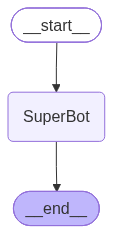

In [21]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Create the graph
graph = StateGraph(State)

# Add node
graph.add_node("SuperBot", superbot)

# Add edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

# Compile the graph
graph_builder = graph.compile()

# Display the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [22]:
graph_builder.invoke({"messages":"my name is uday and i love F1"})

{'messages': [HumanMessage(content='my name is uday and i love F1', additional_kwargs={}, response_metadata={}, id='d2ede305-dc01-469d-b52d-c76e16d34aa8'),
  AIMessage(content="Hello Uday! Nice to meet you! It's great to hear that you're a fan of Formula 1 (F1) racing. The speed, the strategy, the thrill of competition - what's not to love? \n\nWhich team or driver is your favorite? Are you a fan of the likes of Lewis Hamilton, Max Verstappen, or Charles Leclerc? Or perhaps you have a soft spot for a particular team like Ferrari, Mercedes, or Red Bull? Let's chat about all things F1!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 107, 'prompt_tokens': 45, 'total_tokens': 152, 'completion_time': 0.337528908, 'completion_tokens_details': None, 'prompt_time': 0.00788781, 'prompt_tokens_details': None, 'queue_time': 0.152322101, 'total_time': 0.345416718}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_de